# Appeal to API

In [8]:
import requests

In [9]:
root_url = "http://127.0.0.1:8000"

In [10]:
url = f"{root_url}/task"

response = requests.get(url)

print(response.status_code)
print(response.json())

200
{'status': '200'}


In [11]:
url = f"{root_url}/editDB/create_matrix_db"

json_str = r'''
{
  "frameId": 2592904,
  "flag_info": false,
  "fit_format": "FitsInfo",
  "dark": false,
  "remove_single_pixels": false,
  "use_correct_matrix": true,
  "multiplication_on_correct_matrix": true,
  "data_index": null,
  "zipped_file": true,
  "rayleigh": false
}
'''


In [12]:
response = requests.post(
    url,
    data=json_str,
    headers={"Content-Type": "application/json"}
)

print("Status:", response.status_code)


Status: 200


In [13]:
if response.status_code == 200:
    with open("result.pkl", "wb") as f:
        f.write(response.content)

    print("Файл сохранён: result.pkl")
else:
    print(response.text)

Файл сохранён: result.pkl


# Open pkl files

In [16]:
import pickle
import matplotlib.pyplot as plt

In [17]:
with open("result.pkl", "rb") as f:
    obj = pickle.load(f)


In [15]:
print(type(obj))
print(obj)

<class 'numpy.ndarray'>
[[ -215.  -648.  -626. ...  -655.  -679. -1821.]
 [ -139.  -678.  -610. ...  -662.  -694. -1822.]
 [ -135.  -664.  -626. ...  -665.  -661. -1811.]
 ...
 [  -78.  -640.  -639. ...  -668.  -638. -1813.]
 [  -93.  -636.  -597. ...  -663.  -649. -1816.]
 [  -90.  -638.  -621. ...  -659.  -644. -1809.]]


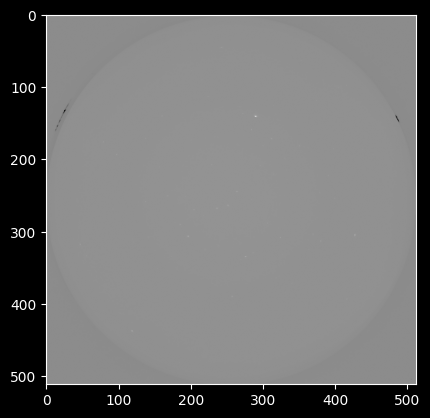

In [18]:
plt.imshow(obj, cmap="gray")

# Getting a list of images by date

In [34]:
import requests
import pickle
import matplotlib.pyplot as plt

In [35]:
root_url = "http://127.0.0.1:8000"

In [36]:
url = f"{root_url}/task"

response = requests.get(url)

# Проверка работы API
print(response.status_code)
print(response.json())

200
{'status': '200'}


In [37]:
url = f"{root_url}/database/frames/by_date"


params = {
    "date_from": "2024-03-04 18:00:00",
    "date_to": "2024-03-04 19:00:00",
}

headers = {
    "accept": "application/json"
}

In [38]:
response = requests.get(url, params=params, headers=headers)

In [39]:
print("URL:", response.url)
print("Status:", response.status_code)

URL: http://127.0.0.1:8000/database/frames/by_date/?date_from=2024-03-04+18%3A00%3A00&date_to=2024-03-04+19%3A00%3A00
Status: 200


In [40]:
if response.status_code == 200:
    data = response.json()
    print(data)
else:
    data = []
    print(response.text)

[{'id': 1824266, 'id_filtr': 1, 'dt_end': '2024-03-04T18:00:55', 'dest': '/data/NFS/True-NAS/optica/ASI0/2024/03/04/6300/20240304_180000_TORY_ASI0_6300_055000ms.fits.gz', 'id_proc': 7, 'id_night': 2024030400, 'dt_beg': '2024-03-04T18:00:00', 'exp': 55000, 'mean_frame': 1283.01}, {'id': 1824267, 'id_filtr': 1, 'dt_end': '2024-03-04T18:03:55', 'dest': '/data/NFS/True-NAS/optica/ASI0/2024/03/04/6300/20240304_180300_TORY_ASI0_6300_055000ms.fits.gz', 'id_proc': 7, 'id_night': 2024030400, 'dt_beg': '2024-03-04T18:03:00', 'exp': 55000, 'mean_frame': 1290.71}, {'id': 1824268, 'id_filtr': 1, 'dt_end': '2024-03-04T18:04:55', 'dest': '/data/NFS/True-NAS/optica/ASI0/2024/03/04/6300/20240304_180400_TORY_ASI0_6300_055000ms.fits.gz', 'id_proc': 7, 'id_night': 2024030400, 'dt_beg': '2024-03-04T18:04:00', 'exp': 55000, 'mean_frame': 1291.5}, {'id': 1824269, 'id_filtr': 1, 'dt_end': '2024-03-04T18:07:55', 'dest': '/data/NFS/True-NAS/optica/ASI0/2024/03/04/6300/20240304_180700_TORY_ASI0_6300_055000ms.fit

In [41]:
data[0]

{'id': 1824266,
 'id_filtr': 1,
 'dt_end': '2024-03-04T18:00:55',
 'dest': '/data/NFS/True-NAS/optica/ASI0/2024/03/04/6300/20240304_180000_TORY_ASI0_6300_055000ms.fits.gz',
 'id_proc': 7,
 'id_night': 2024030400,
 'dt_beg': '2024-03-04T18:00:00',
 'exp': 55000,
 'mean_frame': 1283.01}

In [52]:
url = f"{root_url}/editDB/create_matrix_db"

payload = {
    "frameId": 2592904,
    "flag_info": False,
    "fit_format": "FitsInfo",
    "dark": False,
    "remove_single_pixels": False,
    "use_correct_matrix": False,
    "multiplication_on_correct_matrix": False,
    "data_index": None,
    "zipped_file": True,
    "rayleigh": False,
}

result = []

for frame in data[:2]:
    print(frame["id"])
    payload["frame_id"] = frame["id"]

    response = requests.post(
        url,
        data=json_str,
        headers={"Content-Type": "application/json"}
    )

    file_name = f"{payload["frame_id"]}.pkl"
    if response.status_code == 200:
        with open(file_name, "wb") as f:
            f.write(response.content)
        with open(file_name, "rb") as f:
            obj = pickle.load(f)
        result.append(obj)
    else:
        print(response.text)

1824266
1824267


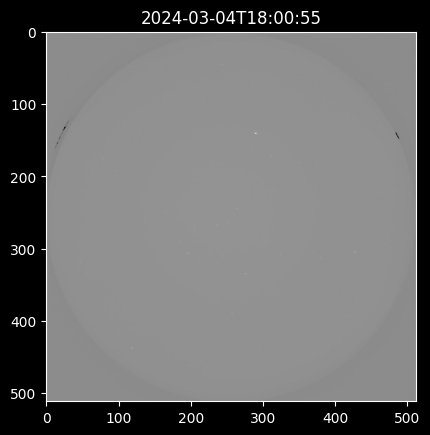

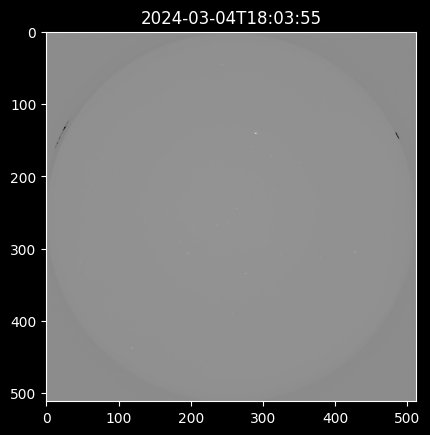

In [53]:
for i, r in enumerate(result):
    plt.title(data[i]["dt_end"])
    plt.imshow(r, cmap="gray")
    plt.show()